In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel(r"C:\Users\2004n\OneDrive\Desktop\Telco-Customer-Churn.xlsx")
print("Dataframe shape",df.shape)

Dataframe shape (7043, 21)


In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,2985,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [7]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors='coerce')
df["TotalCharges"]=df["TotalCharges"].fillna(df["TotalCharges"].median())


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df["Churn_Flag"]=df["Churn"].map({"Yes":1,"No":0})

In [12]:
df[["Churn","Churn_Flag"]]

,Churn,Churn_Flag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1
...,...,...
7038,No,0
7039,No,0
7040,No,0
7041,Yes,1


In [13]:
Churn_rate = df['Churn_Flag'].mean() * 100
print(f"\n Overall Churn Rate: {Churn_rate:.2f}%")


 Overall Churn Rate: 26.54%


In [14]:
# churn by contract type:
Contract_Churn=df.groupby("Contract")["Churn_Flag"].mean()*100
print("\n Churn by Contract :\n",Contract_Churn)


 Churn by Contract :
 Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn_Flag, dtype: float64


In [15]:
# churn by gender type:
Gender_Churn=df.groupby("gender")["Churn_Flag"].mean()*100
print("\n Churn by Gender:\n",Gender_Churn)


 Churn by Gender:
 gender
Female    26.920872
Male      26.160338
Name: Churn_Flag, dtype: float64


In [16]:
# churn by internet service
InternetService_Churn=df.groupby("InternetService")["Churn_Flag"].mean()*100
print("\n Churn by InternetService:\n",InternetService_Churn)


 Churn by InternetService:
 InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn_Flag, dtype: float64


In [17]:
# churn by payment method
PaymentMethod_Churn=df.groupby("PaymentMethod")["Churn_Flag"].mean()*100
print("\n Churn by PaymentMethod:\n",PaymentMethod_Churn)


 Churn by PaymentMethod:
 PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn_Flag, dtype: float64


In [18]:
# Churn by Tenure Groups
df['TenureGroup'] = pd.cut(df['tenure'], 
                           bins=[0,12,24,48,72], 
                           labels=['0-12','13-24','25-48','49-72'])
Tenure_Churn = df.groupby('TenureGroup', observed=False)['Churn_Flag'].mean() * 100
print("\n Churn by Tenure Group:\n", Tenure_Churn)



 Churn by Tenure Group:
 TenureGroup
0-12     47.678161
13-24    28.710938
25-48    20.388959
49-72     9.513176
Name: Churn_Flag, dtype: float64


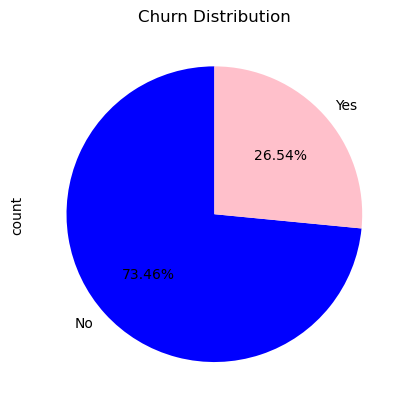

In [19]:
df['Churn'].value_counts().plot.pie(autopct='%1.2f%%',
                                    startangle=90,
                                    colors=['b','pink'])
plt.title("Churn Distribution")
plt.show()

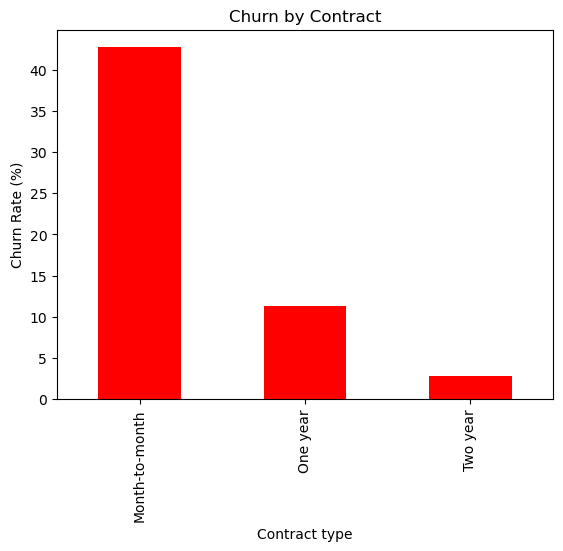

In [20]:
Contract_Churn.plot(kind="bar",color="red")
plt.title("Churn by Contract")
plt.xlabel("Contract type")
plt.ylabel("Churn Rate (%)")
plt.show()

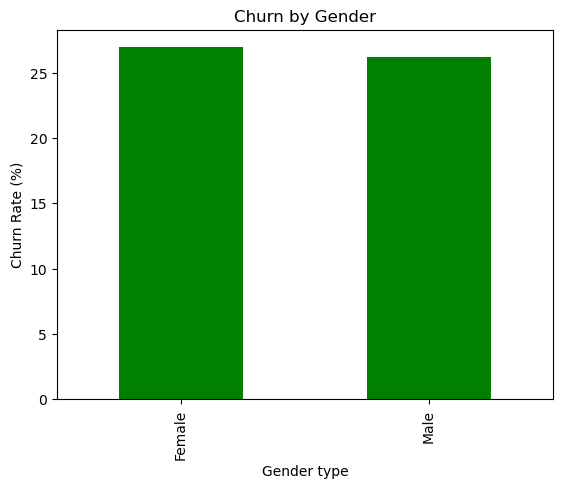

In [21]:
Gender_Churn.plot(kind="bar",color="Green")
plt.title("Churn by Gender")
plt.xlabel("Gender type")
plt.ylabel("Churn Rate (%)")
plt.show()

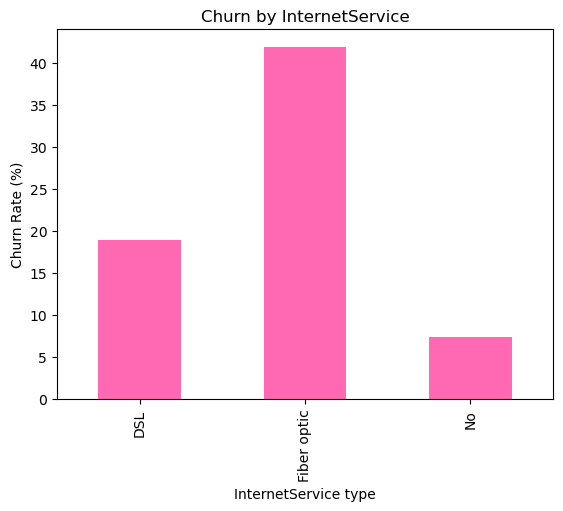

In [22]:
InternetService_Churn.plot(kind="bar",color="hotpink")
plt.title("Churn by InternetService")
plt.xlabel("InternetService type")
plt.ylabel("Churn Rate (%)")
plt.show()


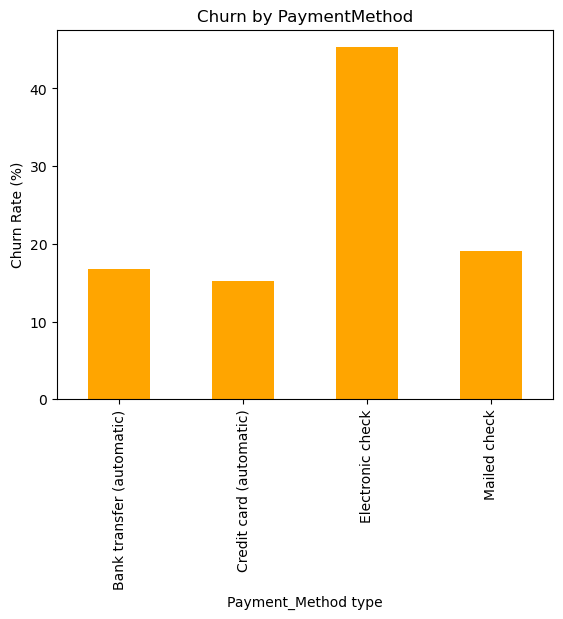

In [23]:
PaymentMethod_Churn.plot(kind="bar",color="orange")
plt.title("Churn by PaymentMethod")
plt.xlabel("Payment_Method type")
plt.ylabel("Churn Rate (%)")
plt.show()

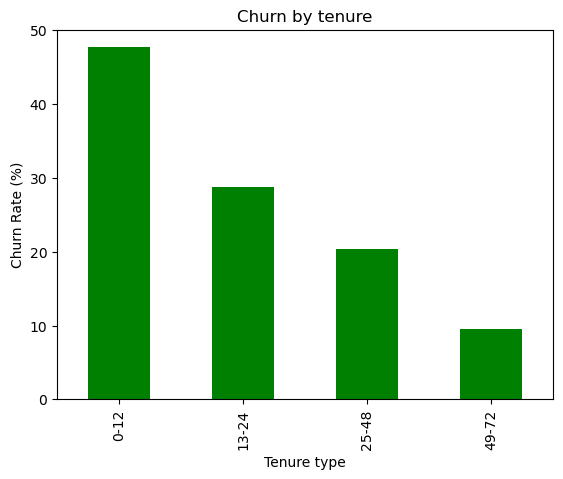

In [43]:
Tenure_Churn.plot(kind="bar",color="Green")
plt.title("Churn by tenure")
plt.xlabel("Tenure type")
plt.ylabel("Churn Rate (%)")
plt.show()